# Focused Loss Landscape

Detailed loss / gradient landscape for a **single** loss and a **single** parameter pair,
rendered at thesis quality (large grid, vector PDF output).

Produces four figures:

1. **2D loss landscape** — filled contour, log color scale
2. **2D gradient landscape** — log-magnitude contour with normalized quiver of $-\nabla\,L$
3. **3D loss surface** — surface with floor-projected contour
4. **3D gradient-magnitude surface** — $\|\nabla L\|_2$ as height, same projection style

All four are saved under `loss_landscape_focus_{loss}_{px}_{py}_{fig}.pdf`.

## 1. Configuration

Edit the four constants below to retarget the figures.

In [13]:
# === USER CONFIG ===========================================================
LOSS_NAME = "VanRossum"          # one of: "MSE", "Guarino", "VanRossum", "Soft-DTW"
X_PARAM   = "E_L"          # x axis parameter (display name: C_m, g_L, E_L, v_T, v_reset)
Y_PARAM   = "g_L"          # y axis parameter
GRID_SIZE = 20             # NxN grid (50 = 2500 sims; 80 = 6400)
# ===========================================================================

In [14]:
import copy
import logging
import time

import jax
import jax.numpy as jnp
import numpy as np
from jax import config
from jax.scipy.special import logsumexp

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, MaxNLocator

from ADoptEX.core import simulate_jaxley
from ADoptEX.core.data import TraceData
from ADoptEX.core.parameters import NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.loss import (
    GuarinoLossConfig,
    MSELossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    inject_spike_peaks,
    make_guarino_loss_fn,
    make_mse_loss_fn,
    make_van_rossum_loss_fn,
)
from ADoptEX.plotting import trace_stim_window_plot
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 2. Synthetic target trace

Generate the ground-truth trace from `NAUD_PARAMETERS["adaptation"]` (hard AdEx).
Spike peaks are injected at detected spike times so the target matches the surrogate-model
output used in the loss factories.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Trace: 4001 samples, 5 spikes


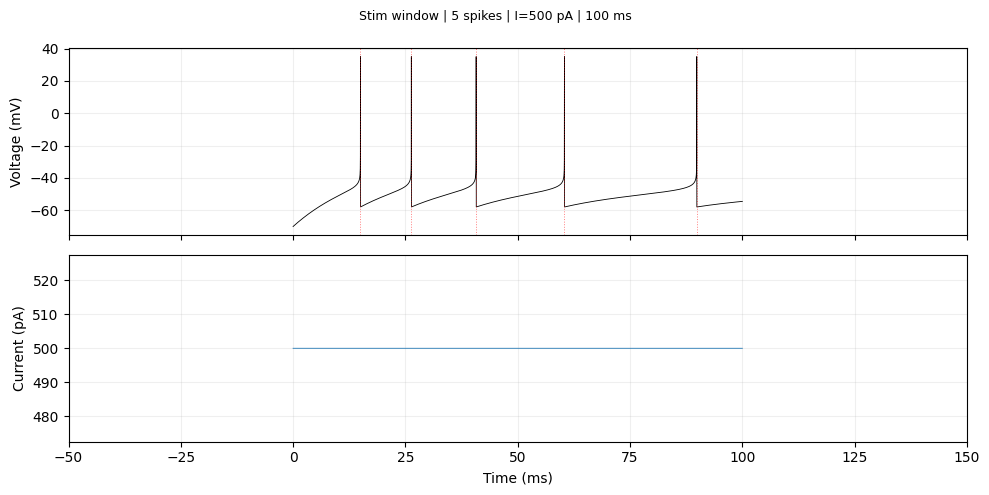

In [15]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0

t_max_ms = 100
dt_ms = 0.025
T = np.linspace(0, t_max_ms, int(t_max_ms / dt_ms))

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=initial_params["I"],
    stim_duration_ms=100,
    dt_ms=dt_ms,
    t_max_ms=t_max_ms,
    stim_delay_ms=0.0,
    use_surrogate=False,
)

SPIKE_PEAK_MV = 35.0
for st in sim_init.spike_times:
    idx = int(st / dt_ms)
    if 0 <= idx < len(sim_init.voltage):
        sim_init.voltage[idx] = SPIKE_PEAK_MV

T = np.append(T, T[-1] + dt_ms)

data = TraceData(
    T,
    sim_init.voltage,
    np.full(len(T), initial_params["I"]),
    dt_ms,
    sim_init.spike_times,
    0,
    len(T),
    initial_params["I"],
)
trace_stim_window_plot(data)
print(f"Trace: {len(T)} samples, {len(sim_init.spike_times)} spikes")

## 3. Trainable cell

Identical setup to the all-pairs notebooks: 5 trainable parameters,
sigmoid surrogate with $\beta = 5$.

In [16]:
training_config = TrainingConfig(
    optimizer="polyak",
    polyak_alpha=0.8,
    polyak_beta=1.0,
    #optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="superspike",
    surrogate_slope=25.0,
    use_param_transform=False,
    clip_to_bounds=False,
    trainable_params=["C_m", "g_L", "E_L", "v_T", "v_reset"],
)

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=np.full(len(T), initial_params["I"]),
    dt_ms=dt_ms,
    config=training_config,
)

target_voltage = jnp.array(sim_init.voltage)
stim_end_index = len(sim_init.voltage)

param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i
PARAM_NAMES = list(param_index.keys())
print(f"Trainable parameters: {PARAM_NAMES}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Trainable parameters: ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset']


## 4. Soft-DTW factory *(only needed when `LOSS_NAME == "Soft-DTW"`)*

Soft-DTW isn't exported from `ADoptEX.loss`; this cell mirrors the inline definition used
in `loss_landscape_synthetic_all_softdtw.ipynb`. Safe to leave executed in all cases —
it only defines functions.

In [17]:
_LARGE = 1e9  # +inf stand-in for soft-DTW boundary cells


def _sliding_window_max(v, window_size, stride):
    return jax.lax.reduce_window(
        v,
        init_value=-jnp.inf,
        computation=jax.lax.max,
        window_dimensions=(window_size,),
        window_strides=(stride,),
        padding="VALID",
    )


def _rescale_unit(v, v_min, v_max, eps=1e-8):
    return (v - v_min) / (v_max - v_min + eps)


def _softmin(values, gamma):
    return -gamma * logsumexp(-values / gamma)


def _soft_dtw_from_cost(C, gamma=1.0):
    n, m = C.shape

    def process_row(R_prev, C_row):
        def col_step(R_curr_prev, inputs):
            R_diag, R_up, C_val = inputs
            R_curr = C_val + _softmin(jnp.stack([R_diag, R_up, R_curr_prev]), gamma)
            return R_curr, R_curr

        col_inputs = (R_prev[:-1], R_prev[1:], C_row)
        _, R_curr_rest = jax.lax.scan(col_step, _LARGE, col_inputs)
        R_curr = jnp.concatenate([jnp.array([_LARGE]), R_curr_rest])
        return R_curr, None

    R_init = jnp.concatenate([jnp.zeros(1), jnp.full(m, _LARGE)])
    R_final, _ = jax.lax.scan(process_row, R_init, C)
    return R_final[-1]


def make_soft_dtw_loss_fn(
    cell, data_stimuli, t_max, dt_ms, exp_voltage, stim_end_index,
    *, window_size=50, stride=30, gamma=0.5, lambda_temp=10.0,
    spike_peak_mv=35.0, use_divergence=True,
):
    import jaxley as jx

    exp_v = jnp.asarray(exp_voltage)
    exp_reduced = _sliding_window_max(exp_v, window_size, stride)
    v_min = float(jnp.min(exp_reduced))
    v_max = float(jnp.max(exp_reduced))
    exp_scaled = _rescale_unit(exp_reduced, v_min, v_max)
    m = exp_scaled.shape[0]

    if use_divergence:
        j_idx_y = jnp.arange(m, dtype=exp_scaled.dtype)
        denom_y = jnp.maximum(jnp.asarray(m - 1, dtype=exp_scaled.dtype), 1.0)
        C_yy = jnp.abs(exp_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(j_idx_y[:, None] - j_idx_y[None, :]) / denom_y
        )
        sdtw_yy = _soft_dtw_from_cost(C_yy, gamma=gamma)
    else:
        sdtw_yy = jnp.asarray(0.0, dtype=exp_scaled.dtype)

    def loss_fn(params):
        results = jx.integrate(
            cell, params=params, data_stimuli=data_stimuli,
            delta_t=dt_ms, t_max=t_max,
        )
        voltage = results[0].flatten()
        min_len = min(len(voltage), len(exp_v))
        sim_v = voltage[:min_len]
        if spike_peak_mv is not None:
            spikes = results[2].flatten()[:min_len]
            sim_v = inject_spike_peaks(sim_v, spikes, spike_peak_mv)
        sim_reduced = _sliding_window_max(sim_v, window_size, stride)
        sim_scaled = _rescale_unit(sim_reduced, v_min, v_max)
        n = sim_scaled.shape[0]
        denom = jnp.maximum(jnp.asarray(max(n, m) - 1, dtype=exp_scaled.dtype), 1.0)
        i_idx = jnp.arange(n, dtype=exp_scaled.dtype)[:, None]
        j_idx = jnp.arange(m, dtype=exp_scaled.dtype)[None, :]
        C_xy = jnp.abs(sim_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_idx - j_idx) / denom
        )
        sdtw_xy = _soft_dtw_from_cost(C_xy, gamma=gamma)
        if not use_divergence:
            return sdtw_xy
        i_only = jnp.arange(n, dtype=exp_scaled.dtype)
        C_xx = jnp.abs(sim_scaled[:, None] - sim_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_only[:, None] - i_only[None, :]) / denom
        )
        sdtw_xx = _soft_dtw_from_cost(C_xx, gamma=gamma)
        return sdtw_xy - 0.5 * (sdtw_xx + sdtw_yy)

    return loss_fn

## 5. Build the requested loss function

In [18]:
if LOSS_NAME == "MSE":
    loss_fn = make_mse_loss_fn(
        cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=dt_ms,
        exp_voltage=target_voltage, stim_end_index=stim_end_index,
        loss_config=MSELossConfig(
            normalize=False, clamp_threshold=None, spike_peak_mv=SPIKE_PEAK_MV,
        ),
    )
    LOSS_UNITS = r"mV$^2$"
elif LOSS_NAME == "Guarino":
    exp_features = extract_experimental_features(
        voltage_trace=target_voltage,
        dt_ms=dt_ms,
        stim_duration_ms=t_max_ms,
        stim_end_index=stim_end_index,
        spike_threshold_mv=-35,
    )
    loss_fn = make_guarino_loss_fn(
        cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=dt_ms,
        exp_features=exp_features,
        stim_duration_ms=t_max_ms, stim_end_index=stim_end_index,
        temperature=1.5, beta=10.0, validity_beta=10.0,
        loss_config=GuarinoLossConfig(weight_spike_count=0.2)
    )
    LOSS_UNITS = None
elif LOSS_NAME == "VanRossum":
    exp_spike_train = jnp.array(sim_init.spikes)
    loss_fn = make_van_rossum_loss_fn(
        cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=dt_ms,
        exp_spike_train=exp_spike_train, stim_end_index=stim_end_index,
        loss_config=VanRossumLossConfig(),
    )
    LOSS_UNITS = None
elif LOSS_NAME == "Soft-DTW":
    loss_fn = make_soft_dtw_loss_fn(
        cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=dt_ms,
        exp_voltage=target_voltage, stim_end_index=stim_end_index,
        window_size=50, stride=30, gamma=0.5, lambda_temp=10.0,
        spike_peak_mv=SPIKE_PEAK_MV,
    )
    LOSS_UNITS = None
else:
    raise ValueError(f"Unknown LOSS_NAME {LOSS_NAME!r}")

loss_init = float(loss_fn(trainable_params))
print(f"Loss: {LOSS_NAME}    initial value: {loss_init:.4g}")

Loss: VanRossum    initial value: 0


## 6. Sweep loss + gradient on a $N \times N$ grid

Both the loss and the partial derivatives w.r.t. the two swept parameters are evaluated at
every grid point. Non-swept parameters stay at their default values.

In [19]:
PARAM_LABELS = {
    "capacitance": r"$C_m$",
    "g_L": r"$g_L$",
    "E_L": r"$E_L$",
    "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$",
    "v_reset": r"$V_\mathrm{reset}$",
    "tau_w": r"$\tau_w$",
    "a": r"$a$",
    "b": r"$b$",
}
_ALIAS_IN  = {"C_m": "capacitance"}
_ALIAS_OUT = {"capacitance": "C_m"}


def _to_internal(name):
    return _ALIAS_IN.get(name, name)


def _param_key(name):
    return name if name == "capacitance" else f"AdEx_{name}"


x_key = _to_internal(X_PARAM)
y_key = _to_internal(Y_PARAM)
if x_key not in param_index or y_key not in param_index:
    raise KeyError(f"Unknown parameter; choose from {PARAM_NAMES}")
if x_key == y_key:
    raise ValueError("X_PARAM and Y_PARAM must differ")

bx, by = PARAM_BOUNDS[x_key], PARAM_BOUNDS[y_key]
x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
y_vals = np.linspace(by.min, by.max, GRID_SIZE)
X, Y = np.meshgrid(x_vals, y_vals)
Z   = np.full((GRID_SIZE, GRID_SIZE), np.nan)
GX  = np.full((GRID_SIZE, GRID_SIZE), np.nan)
GY  = np.full((GRID_SIZE, GRID_SIZE), np.nan)

ix, iy = param_index[x_key], param_index[y_key]
xrc, yrc = _param_key(x_key), _param_key(y_key)
value_and_grad = jax.value_and_grad(loss_fn)

t_start = time.time()
total = GRID_SIZE * GRID_SIZE
n_failed = 0
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        params_rc = copy.deepcopy(trainable_params)
        params_rc[ix] = {xrc: jnp.array([X[r, c]])}
        params_rc[iy] = {yrc: jnp.array([Y[r, c]])}
        try:
            val, gd = value_and_grad(params_rc)
            Z[r, c] = float(val)
            GX[r, c] = float(gd[ix][xrc][0])
            GY[r, c] = float(gd[iy][yrc][0])
        except Exception:
            n_failed += 1
    done = (r + 1) * GRID_SIZE
    elapsed = time.time() - t_start
    eta = elapsed / done * (total - done)
    print(f"  row {r+1:>3d}/{GRID_SIZE}  elapsed={elapsed:5.0f}s  ETA={eta:5.0f}s", end="\r")

MAG = np.sqrt(GX**2 + GY**2)

# Bound-normalised gradient. Without this, parameters with smaller numerical
# bound widths (e.g. g_L spanning ~10 nS vs E_L spanning ~45 mV) produce
# larger raw partial derivatives purely from unit scaling, and the quiver
# direction reflects unit choice rather than landscape geometry. Scaling each
# component by its bound width reads the gradient in "fractional bound steps"
# -- the same parametrisation used by the recovery-radius benchmark
# (theta + delta * direction * (theta_max - theta_min)).
SCALE_X = bx.max - bx.min
SCALE_Y = by.max - by.min
GX_n = GX * SCALE_X
GY_n = GY * SCALE_Y
MAG_n = np.sqrt(GX_n**2 + GY_n**2)

print(f"\nDone in {time.time() - t_start:.0f}s.  failed cells: {n_failed}/{total}")
print(f"  loss range:           [{np.nanmin(Z):.3g}, {np.nanmax(Z):.3g}]")
print(f"  |grad| range (raw):   [{np.nanmin(MAG):.3g}, {np.nanmax(MAG):.3g}]    (mixed units)")
print(f"  |grad . dtheta| range: [{np.nanmin(MAG_n):.3g}, {np.nanmax(MAG_n):.3g}]    (bound-normalised)")

  row  20/20  elapsed=  177s  ETA=    0s
Done in 177s.  failed cells: 0/400
  loss range:           [0.147, 3.32]
  |grad| range (raw):   [0.00027, 1.64e+03]    (mixed units)
  |grad . dtheta| range: [0.0104, 3.58e+04]    (bound-normalised)


In [20]:
# Shared color scales -- clip both 2D and 3D figures at the same percentile so
# the perceptual mapping is consistent across all four plots.
_pos_Z = Z[np.isfinite(Z) & (Z > 0)]
vmin_Z = float(_pos_Z.min()) if _pos_Z.size else 1e-12
vmax_Z = max(float(np.nanpercentile(Z, 95)), vmin_Z * 10)
norm_Z = LogNorm(vmin=vmin_Z, vmax=vmax_Z)
levels_Z = np.geomspace(vmin_Z, vmax_Z, 30)

# Raw |grad| color scale (kept for the 3D gradient surface in figure 4).
_pos_M = MAG[np.isfinite(MAG) & (MAG > 0)]
vmin_M = float(_pos_M.min()) if _pos_M.size else 1e-12
vmax_M = max(float(np.nanpercentile(MAG, 95)), vmin_M * 10)
norm_M = LogNorm(vmin=vmin_M, vmax=vmax_M)
levels_M = np.geomspace(vmin_M, vmax_M, 30)

# Bound-normalised |grad . dtheta| scale -- used by the 2D gradient figure so
# that colormap and quiver share the same definition of magnitude.
_pos_Mn = MAG_n[np.isfinite(MAG_n) & (MAG_n > 0)]
vmin_Mn = float(_pos_Mn.min()) if _pos_Mn.size else 1e-12
vmax_Mn = max(float(np.nanpercentile(MAG_n, 95)), vmin_Mn * 10)
norm_Mn = LogNorm(vmin=vmin_Mn, vmax=vmax_Mn)
levels_Mn = np.geomspace(vmin_Mn, vmax_Mn, 30)

x0 = initial_params[_ALIAS_OUT.get(x_key, x_key)]
y0 = initial_params[_ALIAS_OUT.get(y_key, y_key)]
x_label = PARAM_LABELS[x_key]
y_label = PARAM_LABELS[y_key]
_unit_bracket = f"  [{LOSS_UNITS}]" if LOSS_UNITS else ""
_loss_slug = LOSS_NAME.lower().replace("-", "")
_file_stem = f"loss_landscape_focus_{_loss_slug}_{x_key}_{y_key}"

## 7. Figure 1 — 2D loss landscape

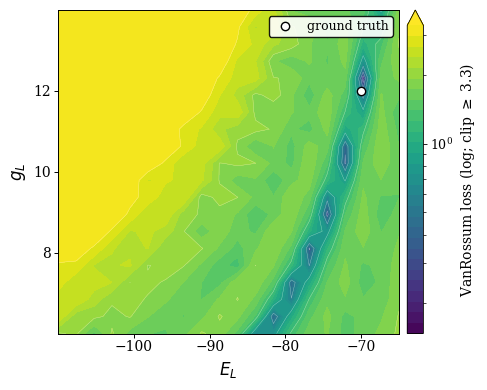

Saved loss_landscape_focus_vanrossum_E_L_g_L_loss2d.pdf


In [21]:
with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
}):
    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    Z_plot = np.clip(Z, vmin_Z, vmax_Z)
    cs = ax.contourf(X, Y, Z_plot, levels=levels_Z, cmap="viridis",
                     norm=norm_Z, extend="max")
    ax.contour(X, Y, Z_plot, levels=levels_Z[::4], colors="white",
               linewidths=0.3, alpha=0.5)
    ax.plot(x0, y0, marker="o", markersize=6,
            markerfacecolor="white", markeredgecolor="black",
            markeredgewidth=1.0, linestyle="none", zorder=5,
            label="ground truth")

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.xaxis.set_major_locator(MaxNLocator(5, prune="both"))
    ax.yaxis.set_major_locator(MaxNLocator(5, prune="both"))
    ax.tick_params(direction="out", length=3, width=0.7, pad=2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
    ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9,
              edgecolor="black", borderpad=0.3)

    cbar = fig.colorbar(cs, ax=ax, extend="max", pad=0.02)
    lo, hi = int(np.floor(np.log10(vmin_Z))), int(np.ceil(np.log10(vmax_Z)))
    cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=min(hi - lo + 1, 8)))
    cbar.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50))
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(which="major", labelsize=9, length=3, width=0.6, pad=1.5)
    cbar.ax.tick_params(which="minor", length=2, width=0.5)
    cbar.outline.set_linewidth(0.6)
    cbar.set_label(rf"{LOSS_NAME} loss{_unit_bracket} (log; clip $\geq$ {vmax_Z:.2g})",
                   fontsize=10, labelpad=4)

    fig.tight_layout()
    out = f"{_file_stem}_loss2d.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

## 8. Figure 2 — 2D gradient landscape

Filled contour: $\log_{10} \|\nabla L \odot \Delta\theta\|_2$, where $\Delta\theta_i = \theta_{\max,i} - \theta_{\min,i}$ is the bound width of the $i$-th parameter. This bound-normalisation puts the two axes on the same dimensionless scale ("fractional bound step"), matching the perturbation parametrisation used by the recovery-radius benchmark in Chapter 5. Without it, raw partial derivatives in mixed units (mV vs nS, etc.) make the quiver direction reflect unit choice rather than landscape geometry.

Overlaid quiver: **normalised gradient direction** of $\nabla L \odot \Delta\theta$ (unit vectors), so arrow length reads as *consistency of direction*, not magnitude. The optimiser steps in the **opposite** direction of each arrow.

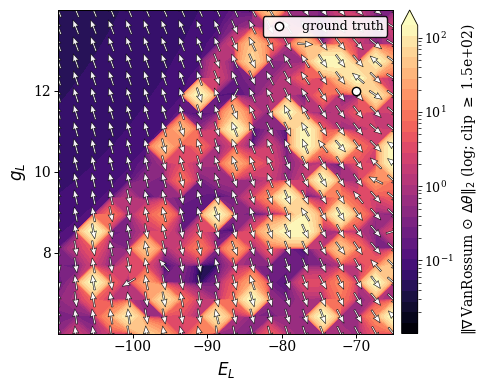

Saved loss_landscape_focus_vanrossum_E_L_g_L_grad2d.pdf


In [22]:
with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
}):
    fig, ax = plt.subplots(figsize=(5.0, 4.0))
    # Use the bound-normalised magnitude so the colormap and the quiver agree:
    # both reflect "fractional bound step" sensitivity, not raw partial
    # derivatives in mixed units. Without this scaling, a parameter with a
    # smaller numerical bound width dominates direction purely from unit
    # choice -- on (E_L, g_L) this makes every arrow appear vertical even
    # when the loss surface is genuinely 2D.
    M_plot = np.clip(MAG_n, vmin_Mn, vmax_Mn)
    cs = ax.contourf(X, Y, M_plot, levels=levels_Mn, cmap="magma",
                     norm=norm_Mn, extend="max")

    # Sub-sample arrows so the field stays readable at 50x50.
    step = max(1, GRID_SIZE // 12)
    Xs, Ys = X[::step, ::step], Y[::step, ::step]
    GXs, GYs = GX_n[::step, ::step], GY_n[::step, ::step]
    Ms = np.sqrt(GXs**2 + GYs**2)
    denom = np.where(Ms > 0, Ms, 1.0)
    U, V = GXs / denom, GYs / denom
    ax.quiver(
        Xs, Ys, U, V,
        color="white", edgecolor="black", linewidth=0.4,
        alpha=0.95, pivot="middle",
        angles="xy", scale_units="width",
        scale=22, width=0.005,
        headwidth=4, headlength=5, headaxislength=4.5,
        minshaft=2, minlength=0.1,
    )
    ax.plot(x0, y0, marker="o", markersize=6,
            markerfacecolor="white", markeredgecolor="black",
            markeredgewidth=1.0, linestyle="none", zorder=5,
            label="ground truth")

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.xaxis.set_major_locator(MaxNLocator(5, prune="both"))
    ax.yaxis.set_major_locator(MaxNLocator(5, prune="both"))
    ax.tick_params(direction="out", length=3, width=0.7, pad=2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
    ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9,
              edgecolor="black", borderpad=0.3)

    cbar = fig.colorbar(cs, ax=ax, extend="max", pad=0.02)
    lo, hi = int(np.floor(np.log10(vmin_Mn))), int(np.ceil(np.log10(vmax_Mn)))
    cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=min(hi - lo + 1, 8)))
    cbar.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50))
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(which="major", labelsize=9, length=3, width=0.6, pad=1.5)
    cbar.ax.tick_params(which="minor", length=2, width=0.5)
    cbar.outline.set_linewidth(0.6)
    cbar.set_label(rf"$\|\nabla\,${LOSS_NAME}$\,\odot\,\Delta\theta\|_2$ (log; clip $\geq$ {vmax_Mn:.2g})",
                   fontsize=10, labelpad=4)

    fig.tight_layout()
    out = f"{_file_stem}_grad2d.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

## 9. Figure 3 — 3D loss surface

Surface + floor-projected contours, log-scaled color. Ground-truth point dropped to the floor
with a thin pin to give the reader a depth cue.

/var/folders/lr/n5b_gtwn3fn_tq12xz4vwplc0000gn/T/ipykernel_32816/1219827030.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


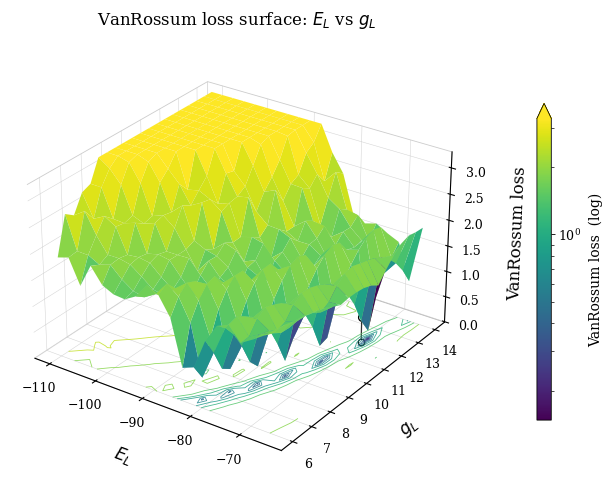

Saved loss_landscape_focus_vanrossum_E_L_g_L_loss3d.pdf


In [23]:
def _plot_3d_surface(Z_in, vmin, vmax, norm, levels, cmap_name, zlabel, out_path, title):
    Z_plot = np.clip(Z_in, vmin, vmax)
    cmap = cm.get_cmap(cmap_name)
    facecolors = cmap(norm(Z_plot))

    with plt.rc_context({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
    }):
        fig = plt.figure(figsize=(6.5, 5.0))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot_surface(
            X, Y, Z_plot,
            facecolors=facecolors,
            rstride=1, cstride=1,
            linewidth=0.08, edgecolor=(1, 1, 1, 0.2),
            antialiased=True, shade=False,
        )

        z_floor = float(np.nanmin(Z_plot)) - 0.05 * (
            float(np.nanmax(Z_plot)) - float(np.nanmin(Z_plot))
        )
        ax.set_zlim(z_floor, float(np.nanmax(Z_plot)))
        contour_levels = np.geomspace(vmin, vmax, 12)
        ax.contour(
            X, Y, Z_plot, levels=contour_levels, zdir="z",
            offset=z_floor, cmap=cmap_name, norm=norm,
            linewidths=0.6, alpha=0.85,
        )

        # Drop a pin at the ground-truth (x0, y0). Interpolate the surface
        # height there so the pin terminates on the surface, not in mid-air.
        try:
            from scipy.interpolate import RegularGridInterpolator
            interp = RegularGridInterpolator(
                (Y[:, 0], X[0, :]), Z_plot, bounds_error=False, fill_value=np.nan
            )
            z0 = float(interp([[y0, x0]])[0])
            if np.isfinite(z0):
                ax.plot([x0, x0], [y0, y0], [z_floor, z0],
                        color="black", linewidth=0.9, alpha=0.8)
                ax.scatter([x0], [y0], [z0], s=32,
                           facecolor="white", edgecolor="black",
                           linewidth=0.9, zorder=5)
        except Exception:
            pass
        ax.scatter([x0], [y0], [z_floor], s=22,
                   facecolor="white", edgecolor="black",
                   linewidth=0.9, zorder=5)

        ax.set_xlabel(x_label, labelpad=8)
        ax.set_ylabel(y_label, labelpad=8)
        ax.set_zlabel(zlabel, labelpad=8)

        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.set_facecolor("white")
            axis.pane.set_edgecolor((0.6, 0.6, 0.6, 0.6))
            axis.pane.set_linewidth(0.6)
            axis._axinfo["grid"].update({"linewidth": 0.4,
                                          "color": (0.8, 0.8, 0.8, 0.8)})
        ax.tick_params(axis="both", which="major", pad=2, length=2.5, width=0.6)
        ax.view_init(elev=28, azim=-55)
        ax.set_box_aspect((1.0, 1.0, 0.65))

        mappable = cm.ScalarMappable(norm=norm, cmap=cmap_name)
        mappable.set_array(Z_plot)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.7, pad=0.12,
                            aspect=22, extend="max")
        lo = int(np.floor(np.log10(vmin)))
        hi = int(np.ceil(np.log10(vmax)))
        cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0,
                                                   numticks=min(hi - lo + 1, 8)))
        cbar.ax.yaxis.set_minor_locator(LogLocator(base=10.0,
                                                   subs=np.arange(2, 10),
                                                   numticks=50))
        cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
        cbar.ax.tick_params(which="major", labelsize=9, length=3, width=0.6, pad=1.5)
        cbar.ax.tick_params(which="minor", length=2, width=0.5)
        cbar.outline.set_linewidth(0.6)
        cbar.set_label(zlabel + r"  (log)", fontsize=10, labelpad=6)

        ax.set_title(title, pad=8)
        fig.tight_layout()
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved {out_path}")


_plot_3d_surface(
    Z, vmin_Z, vmax_Z, norm_Z, levels_Z, "viridis",
    rf"{LOSS_NAME} loss{_unit_bracket}",
    f"{_file_stem}_loss3d.pdf",
    f"{LOSS_NAME} loss surface: {x_label} vs {y_label}",
)

## 10. Figure 4 — 3D gradient-magnitude surface

Same projection style as Figure 3 but with $\|\nabla L\|_2$ on the z axis. Flat / dark
regions are the dangerous zones — they correspond to vanishing gradient where the optimiser
receives no usable signal.

/var/folders/lr/n5b_gtwn3fn_tq12xz4vwplc0000gn/T/ipykernel_32816/1219827030.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


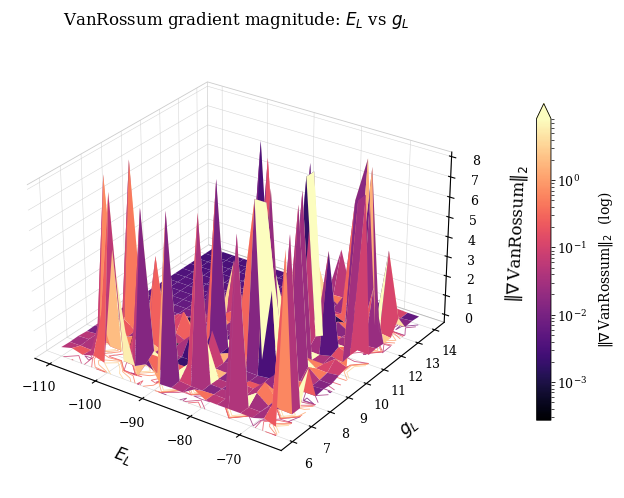

Saved loss_landscape_focus_vanrossum_E_L_g_L_grad3d.pdf


In [24]:
_plot_3d_surface(
    MAG, vmin_M, vmax_M, norm_M, levels_M, "magma",
    rf"$\|\nabla\,${LOSS_NAME}$\|_2$",
    f"{_file_stem}_grad3d.pdf",
    rf"{LOSS_NAME} gradient magnitude: {x_label} vs {y_label}",
)